# 2段階実装

In [37]:
import pandas as pd

def load_experiment_data(csv_path):
    """
    実験CSVを読み込み、可視化に必要な前処理まで行う
    """
    #df = pd.read_csv(csv_path)
    df = pd.read_csv(csv_path, header=None)
    # 数値列の安全変換
    for col in ["non_iid_beta", "score_mean", "svd_ratio", "bias_ratio", "gamma_ratio_krr"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # zerosum がある場合は G_type を正規化
    if "zerosum" in df.columns:
        df.loc[
            (df["G_type"] == "nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "nonlinear_zero"

        df.loc[
            (df["G_type"] == "laplacian_nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "laplacian_nonlinear_zero"

    return df


In [38]:
import matplotlib.pyplot as plt

STYLE = {
    # --- red family ---
    "gep":        {"color": "#d62728", "linestyle": "-",  "marker": "o"},
    "imakura":    {"color": "#d62728", "linestyle": ":",  "marker": "o"},
    "odc":        {"color": "#d62728", "linestyle": "--", "marker": "o"},
    "targetvec":  {"color": "#d62728", "linestyle": "-.", "marker": "o"},

    # --- nonlinear family ---
    "nonlinear":                 {"color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":            {"color": "#2ca02c", "linestyle": "--", "marker": "o"},
    "laplacian_nonlinear":        {"color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":   {"color": "#1f77b4", "linestyle": "--", "marker": "o"},

    # --- baselines ---
    "individual":  {"color": "gray", "linestyle": "-",  "marker": None},
    "centralize":  {"color": "gray", "linestyle": ":",  "marker": None},
    "fl":          {"color": "gray", "linestyle": "--", "marker": None},
}


def plot_experiment(
    df,
    *,
    x_col,
    y_col="score_mean",
    xscale="linear",          # "linear" or "log"
    xlabel=None,
    title=None,
):
    """
    汎用プロット関数
    """
    plt.figure(figsize=(9, 6))

    for g, gdf in df.groupby("G_type"):
        if g not in STYLE:
            continue

        gdf = gdf.dropna(subset=[x_col, y_col]).sort_values(x_col)
        st = STYLE[g]

        plt.plot(
            gdf[x_col],
            gdf[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            label=g
        )

    plt.xscale(xscale)

    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(y_col)

    if title:
        plt.title(title)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [39]:
df = load_experiment_data(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias/result_grid_fashion_mnist_svd_dir.csv",
)

plot_experiment(
    df,
    x_col="non_iid_beta",
    xscale="log",
    xlabel=r"non-IID strength $\beta$",
    title="fashion_mnist (non-IID)"
)

plot_experiment(
    df,
    x_col="svd_ratio",
    xscale="linear",
    xlabel="SVD ratio",
    title="SVD ablation"
)

plot_experiment(
    df,
    x_col="bias_ratio",
    xlabel="Bias ratio",
)



ParserError: Error tokenizing data. C error: Expected 33 fields in line 2, saw 34


In [40]:
df = df.reset_index(drop=False)
df

ValueError: cannot insert level_0, already exists

# 一気通貫実装

In [10]:
DEFAULTS = {
    "bias_ratio": 0.1,
    "smote_ratio": 1.0,
    "svd_ratio": 0,                 # ← 可視化時はここを無視
    "non_iid_beta": 1,
}


In [11]:
import pandas as pd
import matplotlib.pyplot as plt


STYLE = {
    "nonlinear":               {"color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":          {"color": "#2ca02c", "linestyle": "--", "marker": "o"},
    "laplacian_nonlinear":     {"color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":{"color": "#1f77b4", "linestyle": "--", "marker": "o"},
    "faster_gep":                     {"color": "#d62728", "linestyle": "-",  "marker": "o"},
    "imakura":                 {"color": "#d62728", "linestyle": ":",  "marker": "o"},
    "odc":                     {"color": "#d62728", "linestyle": "--", "marker": "o"},
    "targetvec_new":               {"color": "#d62728", "linestyle": "-.", "marker": "o"},
    "individual":              {"color": "gray",    "linestyle": "-",  "marker": None},
    "centralize":              {"color": "gray",    "linestyle": ":",  "marker": None},
    "fl":                      {"color": "gray",    "linestyle": "--", "marker": None},
}


def visualize_with_defaults(
    csv_path,
    *,
    x_col,                     # 例: "svd_ratio"
    y_col="score_mean",
    xscale="linear",            # "linear" or "log"
    xlabel=None,
    title=None,
    defaults=DEFAULTS,
):
    """
    CSV を読み込み、
    - x_col 以外は DEFAULTS と一致する行のみ抽出
    - x_col vs y_col を可視化
    """

    # ------------------
    # Load
    # ------------------
    df = pd.read_csv(csv_path)

    # 数値化
    # for col in df.columns:
    #     try:
    #         df[col] = pd.to_numeric(df[col])
    #     except (ValueError, TypeError):
    #         # 数値に変換できない列はそのまま
    #         pass
    # ------------------
    # DEFAULTS フィルタ
    # ------------------
    for key, val in defaults.items():
        if key == x_col:
            continue              # ← 可視化軸は自由に動かす
        if key not in df.columns:
            continue
        if val is None:
            continue              # None は条件に使わない
        
        df = df[df[key] == val]
    # ------------------
    # zerosum → G_type 整理
    # ------------------
    if "zerosum" in df.columns:
        df.loc[
            (df["G_type"] == "nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "nonlinear_zero"

        df.loc[
            (df["G_type"] == "laplacian_nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "laplacian_nonlinear_zero"

    # ------------------
    # Plot
    # ------------------
    plt.figure(figsize=(9, 6))

    for g, gdf in df.groupby("G_type"):
        if g not in STYLE:
            continue
        gdf = gdf.dropna(subset=[x_col, y_col]).sort_values(x_col)
        st = STYLE[g]
        plt.plot(
            gdf[x_col],
            gdf[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            label=g,
        )


    plt.xscale(xscale)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(y_col)

    if title:
        plt.title(title)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


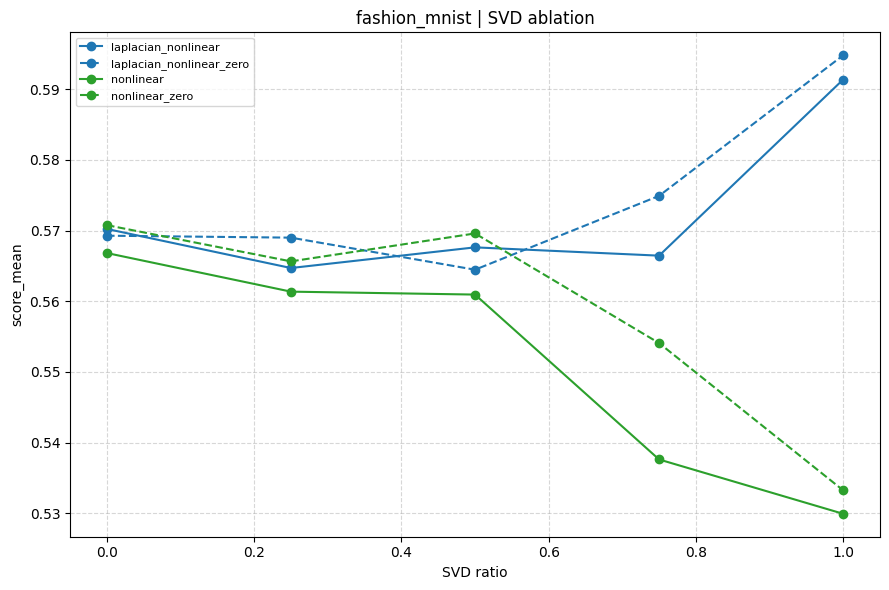

In [12]:
visualize_with_defaults(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias_10/result_grid_fashion_mnist.csv",
    x_col="svd_ratio",
    xlabel="SVD ratio",
    title="fashion_mnist | SVD ablation"
)


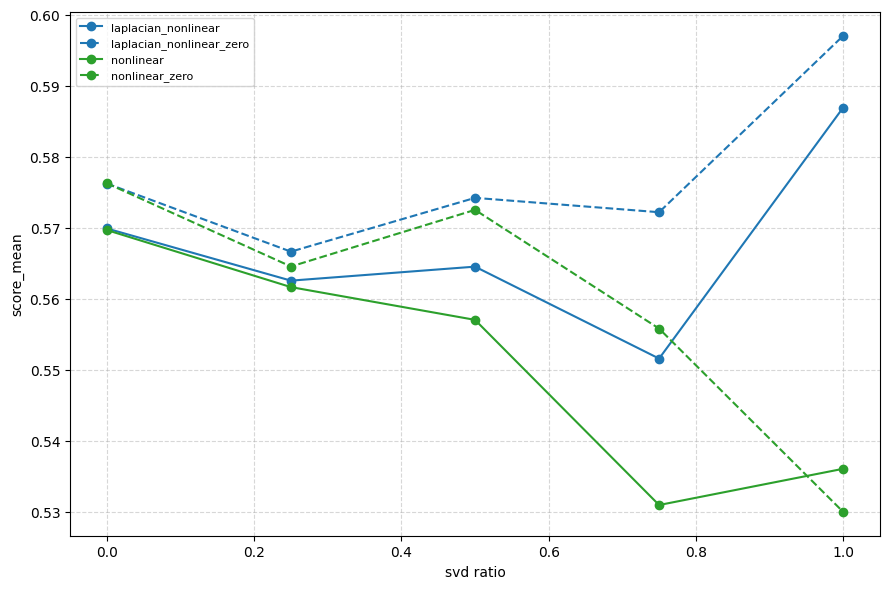

In [13]:
visualize_with_defaults(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias/result_grid_fashion_mnist_svd_dir.csv",
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd ratio",
)


# これ

In [14]:
import pandas as pd

def load_and_filter(csv_path, *, x_col, defaults):
    df = pd.read_csv(csv_path)
    #df = pd.read_csv(csv_path, header=None)
    # ★ index が変なら必ずこれ ★
    #df = df.reset_index(drop=True)
    # 数値化（FutureWarning 回避）
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass
    # ★ ここが重要 ★
    df["G_type"] = df["G_type"].astype(str)
    # DEFAULTS によるフィルタ（x_col 以外）
    for key, val in defaults.items():
        if key == x_col:
            continue
        if key not in df.columns or val is None:
            continue
        df = df[df[key] == val]

    if df.empty:
        raise ValueError("No data left after DEFAULTS filtering.")

    # zerosum → G_type 反映
    if "zerosum" in df.columns:
        df.loc[
            (df["G_type"] == "nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "nonlinear_zero"
        df.loc[
            (df["G_type"] == "laplacian_nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "laplacian_nonlinear_zero"

    return df




In [15]:
import matplotlib.pyplot as plt

STYLE = {
    "gep":        {"color": "#d62728", "linestyle": "-",  "marker": "o"},
    "imakura":    {"color": "#d62728", "linestyle": ":",  "marker": "d"},
    "odc":        {"color": "#d62728", "linestyle": "--", "marker": "s"},
    "targetvec":  {"color": "#d62728", "linestyle": "-.", "marker": "^"},

    "nonlinear":               {"color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":          {"color": "#2ca02c", "linestyle": "--", "marker": "d"},
    "laplacian_nonlinear":     {"color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":{"color": "#1f77b4", "linestyle": "--", "marker": "d"},

    "individual":  {"color": "gray", "linestyle": "-",  "marker": None},
    "centralize":  {"color": "gray", "linestyle": ":",  "marker": None},
    "fl":          {"color": "gray", "linestyle": "--", "marker": None},
}

def plot_filtered(
    df, *, x_col, y_col="score_mean",
    xscale="linear", xlabel=None, title=None
):
    plt.figure(figsize=(9, 6))

    for g, gdf in df.groupby("G_type"):
        if g not in STYLE:
            continue

        gdf = gdf.dropna(subset=[x_col, y_col]).sort_values(x_col)
        if gdf.empty:
            continue

        st = STYLE[g]
        plt.plot(
            gdf[x_col], gdf[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            label=g
        )

    plt.xscale(xscale)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(y_col)

    # legend があるときだけ表示
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(fontsize=8)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [16]:
import os
print(os.getcwd())
print(os.path.exists(r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias/result_grid_fashion_mnist_svd_dir.csv"))


/Users/suetake/git-repos/takano_labo/dca/実験用
True


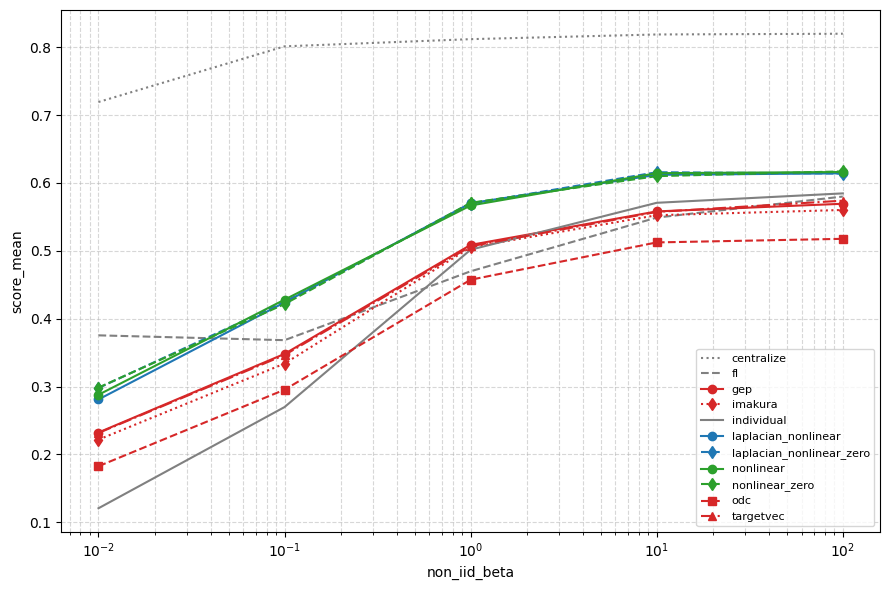

Index([  0,   1,   2,   3,   4,  25,  26,  27,  28,  29,  50,  51,  52,  53,
        54,  75,  76,  77,  78,  79, 100, 101, 102, 103, 104, 125, 126, 127,
       128, 129, 150, 151, 152, 153, 154, 155, 160, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
       180, 181, 182, 183, 200, 201, 212, 213, 214, 215, 216, 217, 218, 219],
      dtype='int64')


In [21]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1219_smote_dir_20/result_grid_fashion_mnist_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)
df
plot_filtered(
    df,
    x_col="non_iid_beta",
    xscale="log",
    xlabel=r"non_iid_beta",
)
print(df.index)

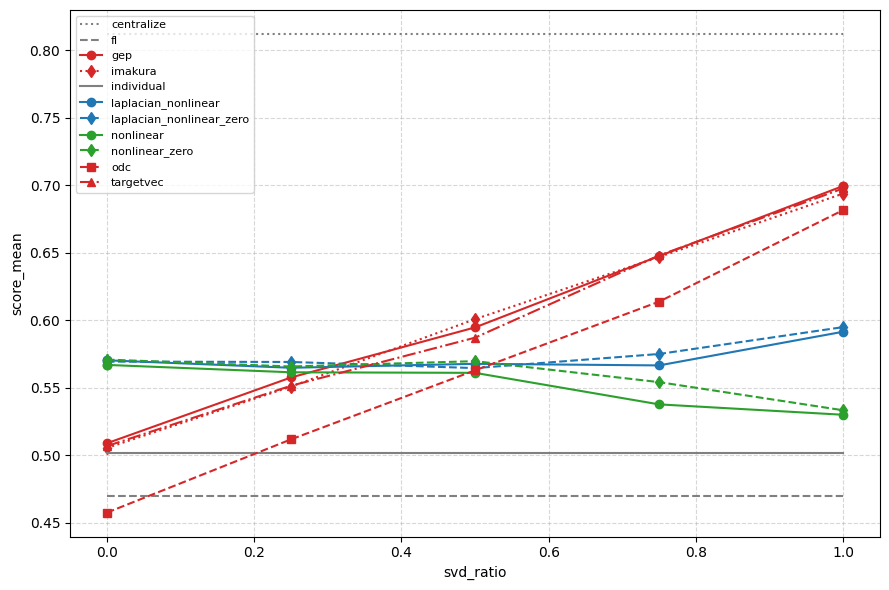

In [22]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1219_smote_dir_20/result_grid_fashion_mnist_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)
plot_filtered(
    df,
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd_ratio",
)